# Clinical Data Processing Pipeline

This notebook contains functions for processing clinical data, particularly for cytogenetic and karyotype analysis.

## Imports

In [1]:
import polars as pl
import numpy as np
import random
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import re
import matplotlib.pyplot as plt

## Karyotype Analysis Functions

In [2]:
def is_male_karyotype(karyotype, male_code='46,xy'):
    """
    Check if a karyotype represents a male (XY).
    
    Parameters:
    -----------
    karyotype : str
        Karyotype string to check
    male_code : str, default='46,xy'
        Code that identifies a male karyotype
        
    Returns:
    --------
    int
        1 if male karyotype, 0 otherwise
    """
    return 1 if karyotype and male_code in karyotype.lower() else 0


def is_female_karyotype(karyotype, female_code='46,xx'):
    """
    Check if a karyotype represents a female (XX).
    
    Parameters:
    -----------
    karyotype : str
        Karyotype string to check
    female_code : str, default='46,xx'
        Code that identifies a female karyotype
        
    Returns:
    --------
    int
        1 if female karyotype, 0 otherwise
    """
    return 1 if karyotype and female_code in karyotype.lower() else 0


def is_a_Man(df, col):
    """
    Add a column indicating if each row represents a male karyotype.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing karyotype data
    col : str
        Column name containing karyotype information
        
    Returns:
    --------
    pl.DataFrame
        DataFrame with added 'is_a_Man' column
    """
    df = df.with_columns(
        pl.col(col).map_elements(lambda x: is_male_karyotype(x))
        .alias("is_a_Man")
    )
    
    return df


def is_a_Female(df, col):
    """
    Add a column indicating if each row represents a female karyotype.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing karyotype data
    col : str
        Column name containing karyotype information
        
    Returns:
    --------
    pl.DataFrame
        DataFrame with added 'is_a_Female' column
    """
    df = df.with_columns(
        pl.col(col).map_elements(lambda x: is_female_karyotype(x))
        .alias("is_a_Female")
    )
    
    return df

## Cytogenetic Analysis Functions

In [3]:
def cyto_regex(cyto, reg_expr):
    """
    Check if a cytogenetic string matches a regular expression pattern.
    
    Parameters:
    -----------
    cyto : str
        Cytogenetic string to check
    reg_expr : str
        Regular expression pattern to match
        
    Returns:
    --------
    int
        1 if pattern matches, 0 otherwise
    """
    if cyto is not None:
        if re.search(reg_expr, cyto, re.IGNORECASE):
            return 1
    return 0


def anomaly_number(cytogenetic, keyword, regex_expr):
    """
    Extract chromosome number from cytogenetic anomaly description.
    
    Parameters:
    -----------
    cytogenetic : str
        Cytogenetic string to analyze
    keyword : str
        Keyword to check for (e.g., 'del', 'inv')
    regex_expr : str
        Regular expression to extract chromosome number
        
    Returns:
    --------
    int
        Chromosome number or -1 if not found
    """
    if cyto_regex(cytogenetic, keyword):
        del_nbr = re.findall(regex_expr, cytogenetic)
        if del_nbr: 
            return int(del_nbr[0])
    return -1 


def transloc_nbr(cytogenetic):
    """
    Extract chromosome numbers involved in translocation.
    
    Parameters:
    -----------
    cytogenetic : str
        Cytogenetic string to analyze
        
    Returns:
    --------
    list
        List of chromosome numbers involved in translocation or [-1] if none found
    """
    if cyto_regex(cytogenetic, 't'):
        trans_nbr = re.findall(r"t\((\d+);(\d+)\)", cytogenetic)
        if trans_nbr:
            flat = [int(x) for tup in trans_nbr for x in tup]
            return flat
    return [-1]


def is_complex(cyto):
    """
    Check if a karyotype is complex (has 3 or more abnormalities).
    
    Parameters:
    -----------
    cyto : str
        Cytogenetic string to analyze
        
    Returns:
    --------
    int
        1 if complex karyotype, 0 otherwise
    """
    return 1 if len(re.findall(r"\+|\-|del|t|inv|add|i\(", cyto)) >= 3 else 0


def is_missing_cytogenetics(df):
    """
    Replace null values in all columns with -1.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame to process
        
    Returns:
    --------
    pl.DataFrame
        DataFrame with null values replaced by -1
    """
    for col in df.columns:
        null_count = df.select(pl.col(col).is_null().sum())[0, 0]
        if null_count > 0:
            df = df.with_columns(
                pl.when(pl.col(col).is_null()).then(-1).otherwise(pl.col(col)).alias(col)
            )
            
    return df

In [4]:

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.impute import IterativeImputer
import category_encoders as ce




def map_lambda(df , col , new_name , function , return_type):
    df = df.with_columns(
        pl.col(col).map_elements(lambda x: function(x) , return_dtype=return_type)
        .alias(new_name)
    )
    
    return df


def map_row(df, col1, col2, new_name, function, return_type):
    return df.with_columns(
        pl.struct([col1, col2]).map_elements(
            lambda row: function(row[col1], row[col2]), return_dtype=return_type
        ).alias(new_name)
    )




def binary_encoder(df, cl_lst):
    df_pd = df.to_pandas()
    
    encoder = ce.BinaryEncoder(cols=cl_lst)
    df_encoded = encoder.fit_transform(df_pd)
    
    return pl.from_pandas(df_encoded)



def strategy_imputation(df , strategy):
    df = df.fill_null(strategy=strategy)

    return df





def imputation_null_values(df, column_list, estimator=None):
    """
    Impute missing values using iterative imputation.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing columns with missing values
    column_list : list
        List of column names to impute
    estimator : object, default=None
        Estimator for IterativeImputer (defaults to RandomForestRegressor if None)

    Returns:
    --------
    pl.DataFrame
        DataFrame with imputed values

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    missing_columns = [col for col in column_list if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns for imputation: {', '.join(missing_columns)}")

    # Check if there are any null values to impute
    null_counts = {col: df.select(pl.col(col).is_null().sum())[0, 0] for col in column_list}
    if sum(null_counts.values()) == 0:
        return df  # No nulls to impute

    try:
        # Select subset of dataframe
        sub_df = df.select(column_list)

        # Convert to pandas
        sub_pd = sub_df.to_pandas()
        

        # Apply imputation
        imputer = IterativeImputer(estimator=estimator, random_state=42)
        imputed_data = imputer.fit_transform(sub_pd)

        # Convert back to polars
        imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

        # Replace nulls in original dataframe
        df = df.with_columns([imputed_pl[col].alias(col) for col in column_list])

        return df
    except Exception as e:
        raise ValueError(f"Error during imputation: {str(e)}")



def iqr_method(df , cl_lst):

    for (index , cl )  in enumerate(cl_lst):
        q1 = df.select(pl.col(cl).quantile(0.25)).item()
        q3 = df.select(pl.col(cl).quantile(0.75)).item()
        
        iqr = q3 - q1
        
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        
        # Winsorisation : capped values
        df = df.with_columns(
            pl.when(pl.col(cl) < lower_bound).then(lower_bound)
            .when(pl.col(cl) > upper_bound).then(upper_bound)
            .otherwise(pl.col(cl))
            .alias(cl)
        )
        
        
        
    return df


def z_score(df, cl_list):
    
    for cl in cl_list:
        mean = df.select(pl.col(cl).mean()).item()
        std = df.select(pl.col(cl).std()).item()

        # Définir les bornes avec Z = ±3
        lower_bound = mean - 3 * std
        upper_bound = mean + 3 * std

        # Appliquer la winsorisation
        df = df.with_columns(
            pl.when(pl.col(cl) < lower_bound).then(lower_bound)
            .when(pl.col(cl) > upper_bound).then(upper_bound)
            .otherwise(pl.col(cl))
            .alias(cl)
        )

    return df

def min_max_normalization(df, column_list):
    """
    Apply min-max normalization to specified columns.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing columns to normalize
    column_list : list
        List of column names to normalize

    Returns:
    --------
    pl.DataFrame
        DataFrame with normalized columns

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    missing_columns = [col for col in column_list if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns for normalization: {', '.join(missing_columns)}")

    try:
        for col in column_list:
            min_val = df[col].min()
            max_val = df[col].max()

            # Avoid division by zero
            if min_val == max_val:
                df = df.with_columns(
                    pl.lit(0.5).alias(col)
                )
            else:
                df = df.with_columns(
                    ((pl.col(col) - min_val)/(max_val - min_val)).alias(col)
                )

        return df
    except Exception as e:
        raise ValueError(f"Error during min-max normalization: {str(e)}")

def Z_scaling(df , col):
    mean = df[col].mean()
    std = df[col].std()
    
    
    df = df.with_columns(
        ((pl.col(col) - mean)/(std)).alias(f"{col}_Z_score")
    )
    
    return df
    

## Main Processing Function

In [5]:
from sklearn.tree import DecisionTreeRegressor


def process_clinical_data(cl_df):
    """
    Process clinical data for cytogenetic analysis.
    
    Parameters:
    -----------
    cl_df : pl.DataFrame
        DataFrame containing clinical data
        
    Returns:
    --------
    pl.DataFrame
        Processed DataFrame with additional features
    """
    # Validate input
    if not isinstance(cl_df, pl.DataFrame):
        raise TypeError("Input must be a polars DataFrame")
    
    # Handle outliers in clinical measurements
    cl_df = iqr_method(cl_df, ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"])
    
    # Imputation of missing values for clinical measurements
    cl_df = imputation_null_values(cl_df, ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"], estimator=DecisionTreeRegressor())
    
    # # Encode categorical variables
    # cl_df = binary_encoder(cl_df, ["CENTER"])
    
    # Gender identification from karyotype
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_a_Man", is_male_karyotype, pl.Int32)
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_a_Female", is_female_karyotype, pl.Int32)
    
    # Cytogenetic abnormalities detection
    
    # Deletion anomalies
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_deletion_anomaly", lambda x: cyto_regex(x, reg_expr=r'del'), pl.Int32)
    
    # Inversion anomalies
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_inversion_anomaly", lambda x: cyto_regex(x, reg_expr=r'inv'), pl.Int32)
    
    # Addition anomalies
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_added_anomaly", lambda x: cyto_regex(x, reg_expr=r'add'), pl.Int32)
    
    # Common chromosomal abnormalities
    
    # Down Syndrome (Trisomy 21)
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_down_syndrome", lambda x: cyto_regex(x, reg_expr=r'\+21'), pl.Int32)
    
    # Monosomy 7
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_monosomy", lambda x: cyto_regex(x, reg_expr=r'\-7'), pl.Int32)
    
    # Partial deletion of 7th chromosome
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_7_deleted", lambda x: cyto_regex(x, reg_expr=r'del\(7\)'), pl.Int32)
    
    # Trisomy 8
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_trisomy_8", lambda x: cyto_regex(x, reg_expr=r'\+8'), pl.Int32)
    
    # Other structural abnormalities
    
    # Isochromosome
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "iso_chromosome", lambda x: cyto_regex(x, reg_expr=r"i\(\d+\)|iso\(\d.+\)"), pl.Int64)
    
    # Derived chromosome
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_derived_chromosome", lambda x: cyto_regex(x, reg_expr=r"der\(\d+\)"), pl.Int64)
    
    # Sex chromosome abnormalities
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_lost_sex_chromosome", lambda x: cyto_regex(x, reg_expr=r"\-[xy]"), pl.Int64)
    
    # Numerical abnormalities
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_added_chromsome", lambda x: cyto_regex(x, reg_expr=r",\+\d+"), pl.Int64)
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_deleted_chromsome", lambda x: cyto_regex(x, reg_expr=r",\-\d+"), pl.Int64)
    
    # Insertion abnormalities
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_inserted_chromsome", lambda x: cyto_regex(x, reg_expr=r"ins"), pl.Int64)
    
    # Translocation anomaly
    cl_df = map_lambda(cl_df , "CYTOGENETICS" , "is_translocated_anomaly" , lambda x: cyto_regex(x ,reg_expr=r't' ) , pl.Int32)
    
    # Complex karyotype detection
    cl_df = map_lambda(cl_df, "CYTOGENETICS", "is_complex_karyo", is_complex, pl.Int64)
    
    # Handle missing cytogenetic data
    cl_df = is_missing_cytogenetics(cl_df)
    
    # Normalize clinical measurements
    col_to_normalize = ["BM_BLAST", "WBC", "ANC", "HB", "PLT"]
    cl_df = min_max_normalization(cl_df, col_to_normalize)
    
    return cl_df

## Example Usage

In [6]:
cl_df = pl.read_csv("../data/raw/X_train/clinical_train.csv")

cl_df

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,f64,f64,f64,f64,f64,f64,str
"""P132697""","""MSK""",14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…"
"""P132698""","""MSK""",1.0,7.4,2.4,0.1,11.6,42.0,"""46,xx"""
"""P116889""","""MSK""",15.0,3.7,2.1,0.1,14.2,81.0,"""46,xy,t(3;3)(q25;q27)[8]/46,xy…"
"""P132699""","""MSK""",1.0,3.9,1.9,0.1,8.9,77.0,"""46,xy,del(3)(q26q27)[15]/46,xy…"
"""P132700""","""MSK""",6.0,128.0,9.7,0.9,11.1,195.0,"""46,xx,t(3;9)(p13;q22)[10]/46,x…"
…,…,…,…,…,…,…,…,…
"""P121828""","""VU""",1.0,3.7,2.53,0.53,8.9,499.0,"""46,xy[20]"""
"""P121829""","""VU""",0.0,4.2,2.4,0.22,10.6,49.0,"""46,xy,del(13)(q12q14)[1]/45,x,…"
"""P121830""","""VU""",0.0,1.8,0.55,0.29,9.4,86.0,"""46,xy,del(20)(q11.2q13.1)[4]/4…"


# Univariate Analysis

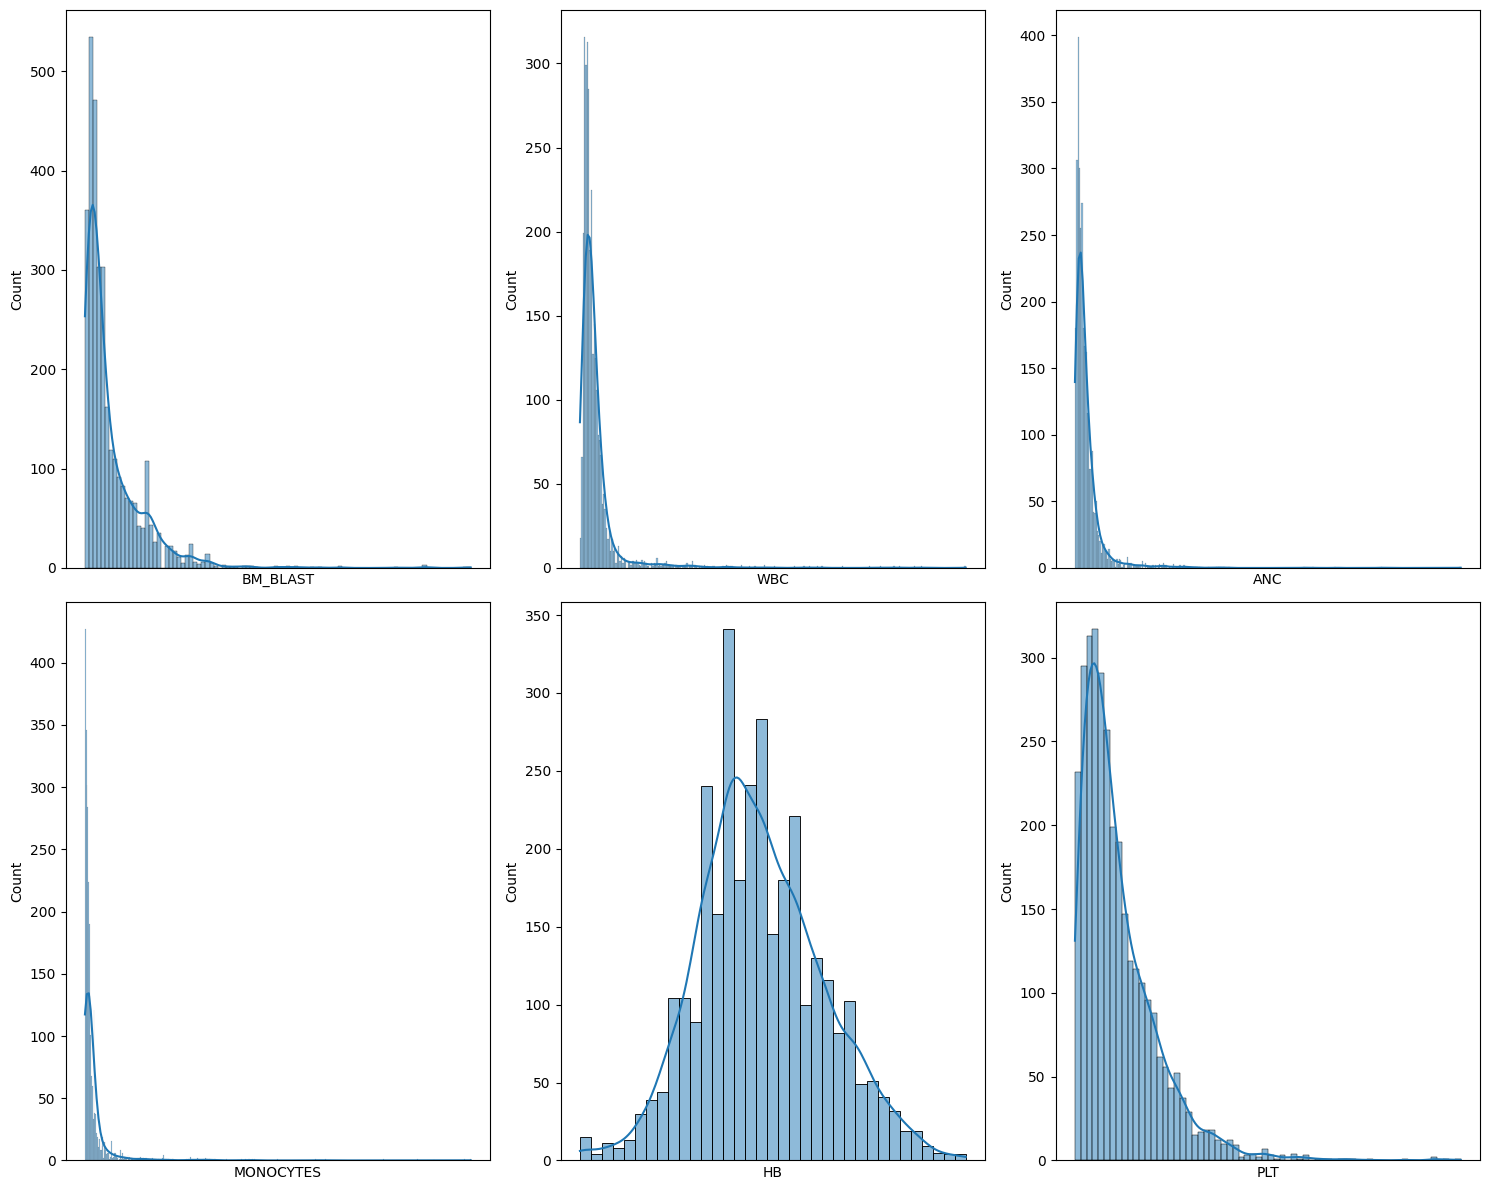

In [7]:
import math
import seaborn as sns

col_int = [col for (col , dtype) in zip(cl_df.columns,cl_df.dtypes) if dtype in [pl.Int64 , pl.Float64]]


num_cols = len(col_int)
num_rows = math.ceil(num_cols / 3)

plt.figure(figsize = (15,12))


for i, cols in enumerate(col_int , 1):
    plt.subplot(num_rows,3,i)
    sns.histplot(data =  cl_df , x = cols , kde=True)
    plt.xticks([])
plt.tight_layout()
plt.show()

In [8]:
int_col = [col for (col,dtype) in zip(cl_df.columns , cl_df.dtypes) if dtype in [pl.Int64 , pl.Float64]]

int_col



['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']

In [9]:
cl_df["CYTOGENETICS"].value_counts().top_k(k=5 , by="count")

CYTOGENETICS,count
str,u32
"""46,xy[20]""",432
null,387
"""46,xy""",276
"""46,xx[20]""",254
"""46,xx""",192


# Bivariate Analysis

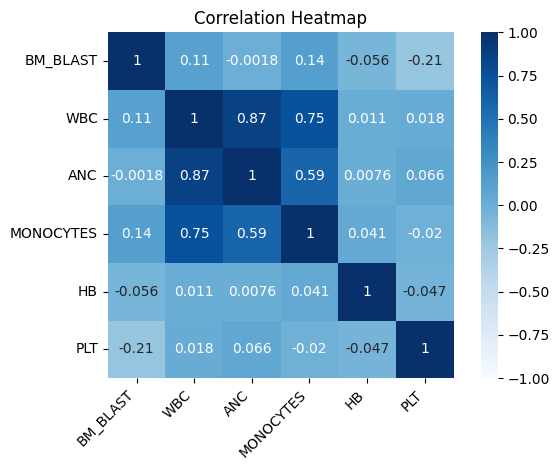

In [10]:
from scipy.stats import pearsonr


int_col = [col for (col,dtype) in zip(cl_df.columns , cl_df.dtypes) if dtype in [pl.Int64 , pl.Float64]]

mol_int = cl_df.select(int_col)
            
mol_int = mol_int.drop_nulls()           

matrix = mol_int.corr()

axis_corr = sns.heatmap(
matrix,
vmin=-1, vmax=1, center=0,
cmap="Blues",
annot=True,
square=True,
xticklabels=matrix.columns,
yticklabels=matrix.columns
)


plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


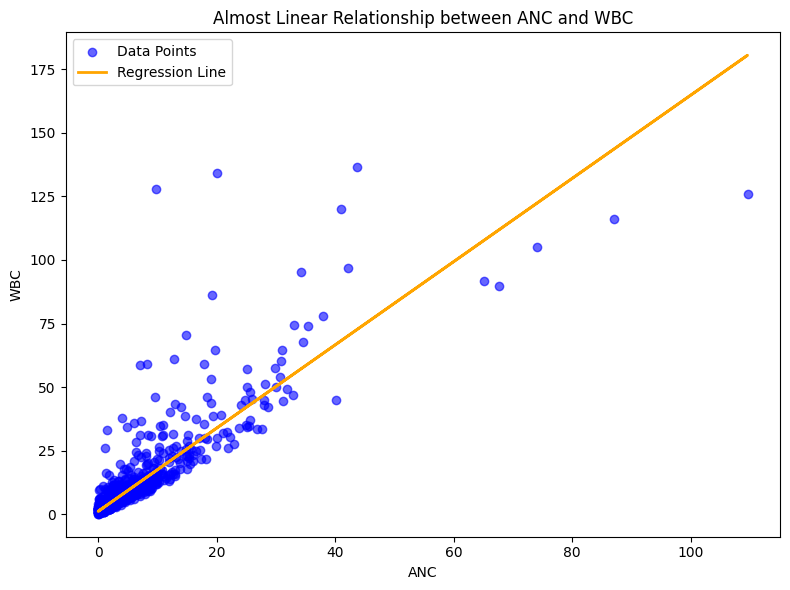

In [11]:
x = mol_int["ANC"]
y = mol_int["WBC"]

# Droite de régression (moindre carrés)
slope, intercept = np.polyfit(x, y, deg=1)
line = slope * x + intercept

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c='blue', alpha=0.6, label="Data Points")  # Scatter en bleu
plt.plot(x, line, color='orange', linewidth=2, label="Regression Line")  # Droite orange

# Labels et titre
plt.xlabel("ANC")
plt.ylabel("WBC")
plt.title("Almost Linear Relationship between ANC and WBC")
plt.legend()
plt.tight_layout()
plt.show()

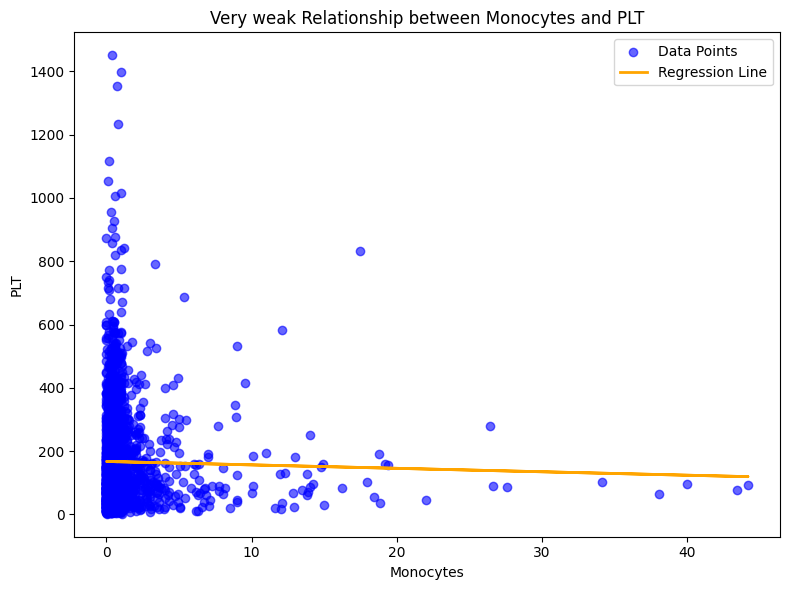

In [12]:
x = mol_int["MONOCYTES"]
y = mol_int["PLT"]

# Droite de régression (moindre carrés)
slope, intercept = np.polyfit(x, y, deg=1)
line = slope * x + intercept

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c='blue', alpha=0.6, label="Data Points")  # Scatter en bleu
plt.plot(x, line, color='orange', linewidth=2, label="Regression Line")  # Droite orange

# Labels et titre
plt.xlabel("Monocytes")
plt.ylabel("PLT")
plt.title("Very weak Relationship between Monocytes and PLT")
plt.legend()
plt.tight_layout()
plt.show()

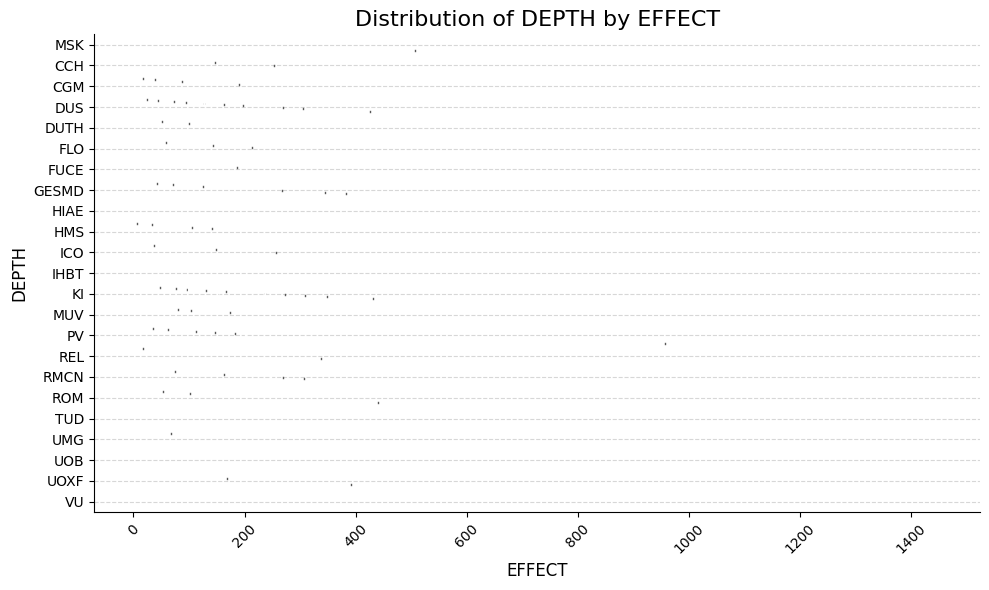

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.violinplot(
    x="PLT",
    y="CENTER",
    data=cl_df,
    hue="PLT",              # Optional if EFFECT is already x-axis
    palette="Set2",            # Softer, aesthetically pleasing colors
    saturation=0.85,
    cut=0,                     # Prevents extrapolation beyond data range
    linewidth=1
)

# Clean legend if hue = x
plt.legend([], [], frameon=False)

# Titles and labels
plt.title("Distribution of DEPTH by EFFECT", fontsize=16)
plt.xlabel("EFFECT", fontsize=12)
plt.ylabel("DEPTH", fontsize=12)

# Style and layout
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()


In [39]:
import pandas as pd

pd_mol = cl_df.to_pandas()

crosstab = pd.crosstab(pd_mol.CENTER , pd_mol.WBC)

crosstab

WBC,0.20,0.21,0.30,0.37,0.40,0.50,0.60,0.70,0.72,0.80,...,95.10,96.80,105.00,116.00,120.10,126.00,128.00,134.00,136.53,154.40
CENTER,,,,,,,,,,,,,,,,,,,,,
CCH,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CGM,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
DUS,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
DUTH,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FLO,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FUCE,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
GESMD,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HIAE,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
HMS,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
cl_df = process_clinical_data(cl_df)

cl_df

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo
str,str,f64,f64,f64,f64,f64,f64,str,i32,i32,i32,i32,i32,i32,i32,i32,i32,i64,i64,i64,i64,i64,i64,i32,i64
"""P132697""","""MSK""",0.756757,0.209677,0.02589,0.7,0.291667,0.246835,"""46,xy,del(20)(q12)[2]/46,xy[18…",1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P132698""","""MSK""",0.054054,0.580645,0.31068,0.1,0.662037,0.084388,"""46,xx""",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P116889""","""MSK""",0.810811,0.282258,0.271845,0.1,0.902778,0.166667,"""46,xy,t(3;3)(q25;q27)[8]/46,xy…",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
"""P132699""","""MSK""",0.054054,0.298387,0.245955,0.1,0.412037,0.158228,"""46,xy,del(3)(q26q27)[15]/46,xy…",1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P132700""","""MSK""",0.324324,1.0,1.0,0.9,0.615741,0.407173,"""46,xx,t(3;9)(p13;q22)[10]/46,x…",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""","""VU""",0.054054,0.282258,0.327508,0.53,0.412037,1.0,"""46,xy[20]""",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P121829""","""VU""",0.0,0.322581,0.31068,0.22,0.569444,0.099156,"""46,xy,del(13)(q12q14)[1]/45,x,…",1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1
"""P121830""","""VU""",0.0,0.129032,0.071197,0.29,0.458333,0.177215,"""46,xy,del(20)(q11.2q13.1)[4]/4…",1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0


In [15]:
col_to_drop = [col for col , dtype in zip(cl_df.columns , cl_df.dtypes) if dtype == pl.Utf8]

col_to_drop.remove("ID")

cl_df = cl_df.drop(col_to_drop)


In [16]:
cl_df

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo
str,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i64,i64,i64,i64,i64,i64,i32,i64
"""P132697""",0.756757,0.209677,0.02589,0.7,0.291667,0.246835,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P132698""",0.054054,0.580645,0.31068,0.1,0.662037,0.084388,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P116889""",0.810811,0.282258,0.271845,0.1,0.902778,0.166667,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
"""P132699""",0.054054,0.298387,0.245955,0.1,0.412037,0.158228,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P132700""",0.324324,1.0,1.0,0.9,0.615741,0.407173,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""",0.054054,0.282258,0.327508,0.53,0.412037,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P121829""",0.0,0.322581,0.31068,0.22,0.569444,0.099156,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1
"""P121830""",0.0,0.129032,0.071197,0.29,0.458333,0.177215,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0


# SAVING THE PREPROCESSED DATAFRAME

In [17]:
pre_processed_clinical = cl_df.write_csv("../data/processed/X_train/clinical_train_preprocess.csv")

In [2]:
cl_test = pl.read_csv("../data/raw/X_test/clinical_test.csv")

cl_test

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,f64,f64,f64,str,f64,f64,str
"""KYW1""","""KYW""",68.0,3.45,0.5865,null,7.6,48.0,"""47,XY,+X,del(9)(q?)[15]/47,XY,…"
"""KYW2""","""KYW""",35.0,3.18,1.2402,null,10.0,32.0,"""46,XY,der(3)?t(3;11)(q26.2;q23…"
"""KYW3""","""KYW""",null,12.4,8.68,null,12.3,25.0,"""47,XX,+8"""
"""KYW4""","""KYW""",61.0,5.55,2.0535,null,8.0,44.0,"""Normal"""
"""KYW5""","""KYW""",2.0,1.21,0.7381,null,8.6,27.0,"""43,XY,dic(5;17)(q11.2;p11.2),-…"
…,…,…,…,…,…,…,…,…
"""KYW1189""","""KYW""",null,null,null,null,null,null,null
"""KYW1190""","""KYW""",null,null,null,null,null,null,null
"""KYW1191""","""KYW""",null,null,null,null,null,null,null
